![Title slide](title_slide.png)

# 1. Introduction

In this part we will investigate another target variable - global_subjectivity. This would be probably not the most insightful variable for data analysts, but as we already covered the `shares`, which were said by the authors to be the target, now we will focus on the variable which histogram was normally distributed.

Most of the steps will be conducted in the similar pattern.

# 2. Data Preprocessing

In [1]:
# Libraries import
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
import math
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
from sklearn.model_selection import RandomizedSearchCV
import matplotlib.pyplot as plt
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from xgboost import XGBRegressor



In [2]:
csv_path = 'OnlineNewsPopularity.csv'

df = pd.read_csv(csv_path)
print(f'Loaded local file: {csv_path}')
display(df.head())


Loaded local file: OnlineNewsPopularity.csv


,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


In [3]:
# Show column names cleanly
cols = df.columns.tolist()
print("Number of columns:", len(cols))
for c in cols:
    print(repr(c))

Number of columns: 61
'url'
' timedelta'
' n_tokens_title'
' n_tokens_content'
' n_unique_tokens'
' n_non_stop_words'
' n_non_stop_unique_tokens'
' num_hrefs'
' num_self_hrefs'
' num_imgs'
' num_videos'
' average_token_length'
' num_keywords'
' data_channel_is_lifestyle'
' data_channel_is_entertainment'
' data_channel_is_bus'
' data_channel_is_socmed'
' data_channel_is_tech'
' data_channel_is_world'
' kw_min_min'
' kw_max_min'
' kw_avg_min'
' kw_min_max'
' kw_max_max'
' kw_avg_max'
' kw_min_avg'
' kw_max_avg'
' kw_avg_avg'
' self_reference_min_shares'
' self_reference_max_shares'
' self_reference_avg_sharess'
' weekday_is_monday'
' weekday_is_tuesday'
' weekday_is_wednesday'
' weekday_is_thursday'
' weekday_is_friday'
' weekday_is_saturday'
' weekday_is_sunday'
' is_weekend'
' LDA_00'
' LDA_01'
' LDA_02'
' LDA_03'
' LDA_04'
' global_subjectivity'
' global_sentiment_polarity'
' global_rate_positive_words'
' global_rate_negative_words'
' rate_positive_words'
' rate_negative_words'
' avg_

In [4]:
# Remove leading spaces from column names
df.columns = df.columns.str.strip()

In [5]:
# Basic checks
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:\n", df.dtypes)

# Missing values
missing = df.isna().sum().sort_values(ascending=False)
print("\nMissing values (top):\n", missing.head(10))

# Duplicates
print("\nDuplicate rows:", df.duplicated().sum())

Shape: (39644, 61)

Columns: ['url', 'timedelta', 'n_tokens_title', 'n_tokens_content', 'n_unique_tokens', 'n_non_stop_words', 'n_non_stop_unique_tokens', 'num_hrefs', 'num_self_hrefs', 'num_imgs', 'num_videos', 'average_token_length', 'num_keywords', 'data_channel_is_lifestyle', 'data_channel_is_entertainment', 'data_channel_is_bus', 'data_channel_is_socmed', 'data_channel_is_tech', 'data_channel_is_world', 'kw_min_min', 'kw_max_min', 'kw_avg_min', 'kw_min_max', 'kw_max_max', 'kw_avg_max', 'kw_min_avg', 'kw_max_avg', 'kw_avg_avg', 'self_reference_min_shares', 'self_reference_max_shares', 'self_reference_avg_sharess', 'weekday_is_monday', 'weekday_is_tuesday', 'weekday_is_wednesday', 'weekday_is_thursday', 'weekday_is_friday', 'weekday_is_saturday', 'weekday_is_sunday', 'is_weekend', 'LDA_00', 'LDA_01', 'LDA_02', 'LDA_03', 'LDA_04', 'global_subjectivity', 'global_sentiment_polarity', 'global_rate_positive_words', 'global_rate_negative_words', 'rate_positive_words', 'rate_negative_words

# 3. Explanatory Data Analysis and Feature Engineering

### Correlation Heatmap

In [6]:
corr_matrix = df.corr(numeric_only=True)

# Correlation with target
target_corr = corr_matrix["global_subjectivity"].sort_values(ascending=False)

display(target_corr)
display(target_corr)

global_subjectivity              1.000000
avg_positive_polarity            0.631749
average_token_length             0.597629
max_positive_polarity            0.518773
rate_positive_words              0.487481
global_rate_positive_words       0.467063
global_sentiment_polarity        0.339436
global_rate_negative_words       0.253181
min_positive_polarity            0.243984
num_hrefs                        0.203464
timedelta                        0.133837
rate_negative_words              0.132940
n_tokens_content                 0.127879
num_self_hrefs                   0.115285
title_subjectivity               0.114123
abs_title_sentiment_polarity     0.091067
num_videos                       0.082052
LDA_03                           0.080887
num_imgs                         0.080468
self_reference_avg_sharess       0.071115
kw_avg_avg                       0.065515
self_reference_max_shares        0.064379
data_channel_is_lifestyle        0.060423
LDA_04                           0

global_subjectivity              1.000000
avg_positive_polarity            0.631749
average_token_length             0.597629
max_positive_polarity            0.518773
rate_positive_words              0.487481
global_rate_positive_words       0.467063
global_sentiment_polarity        0.339436
global_rate_negative_words       0.253181
min_positive_polarity            0.243984
num_hrefs                        0.203464
timedelta                        0.133837
rate_negative_words              0.132940
n_tokens_content                 0.127879
num_self_hrefs                   0.115285
title_subjectivity               0.114123
abs_title_sentiment_polarity     0.091067
num_videos                       0.082052
LDA_03                           0.080887
num_imgs                         0.080468
self_reference_avg_sharess       0.071115
kw_avg_avg                       0.065515
self_reference_max_shares        0.064379
data_channel_is_lifestyle        0.060423
LDA_04                           0

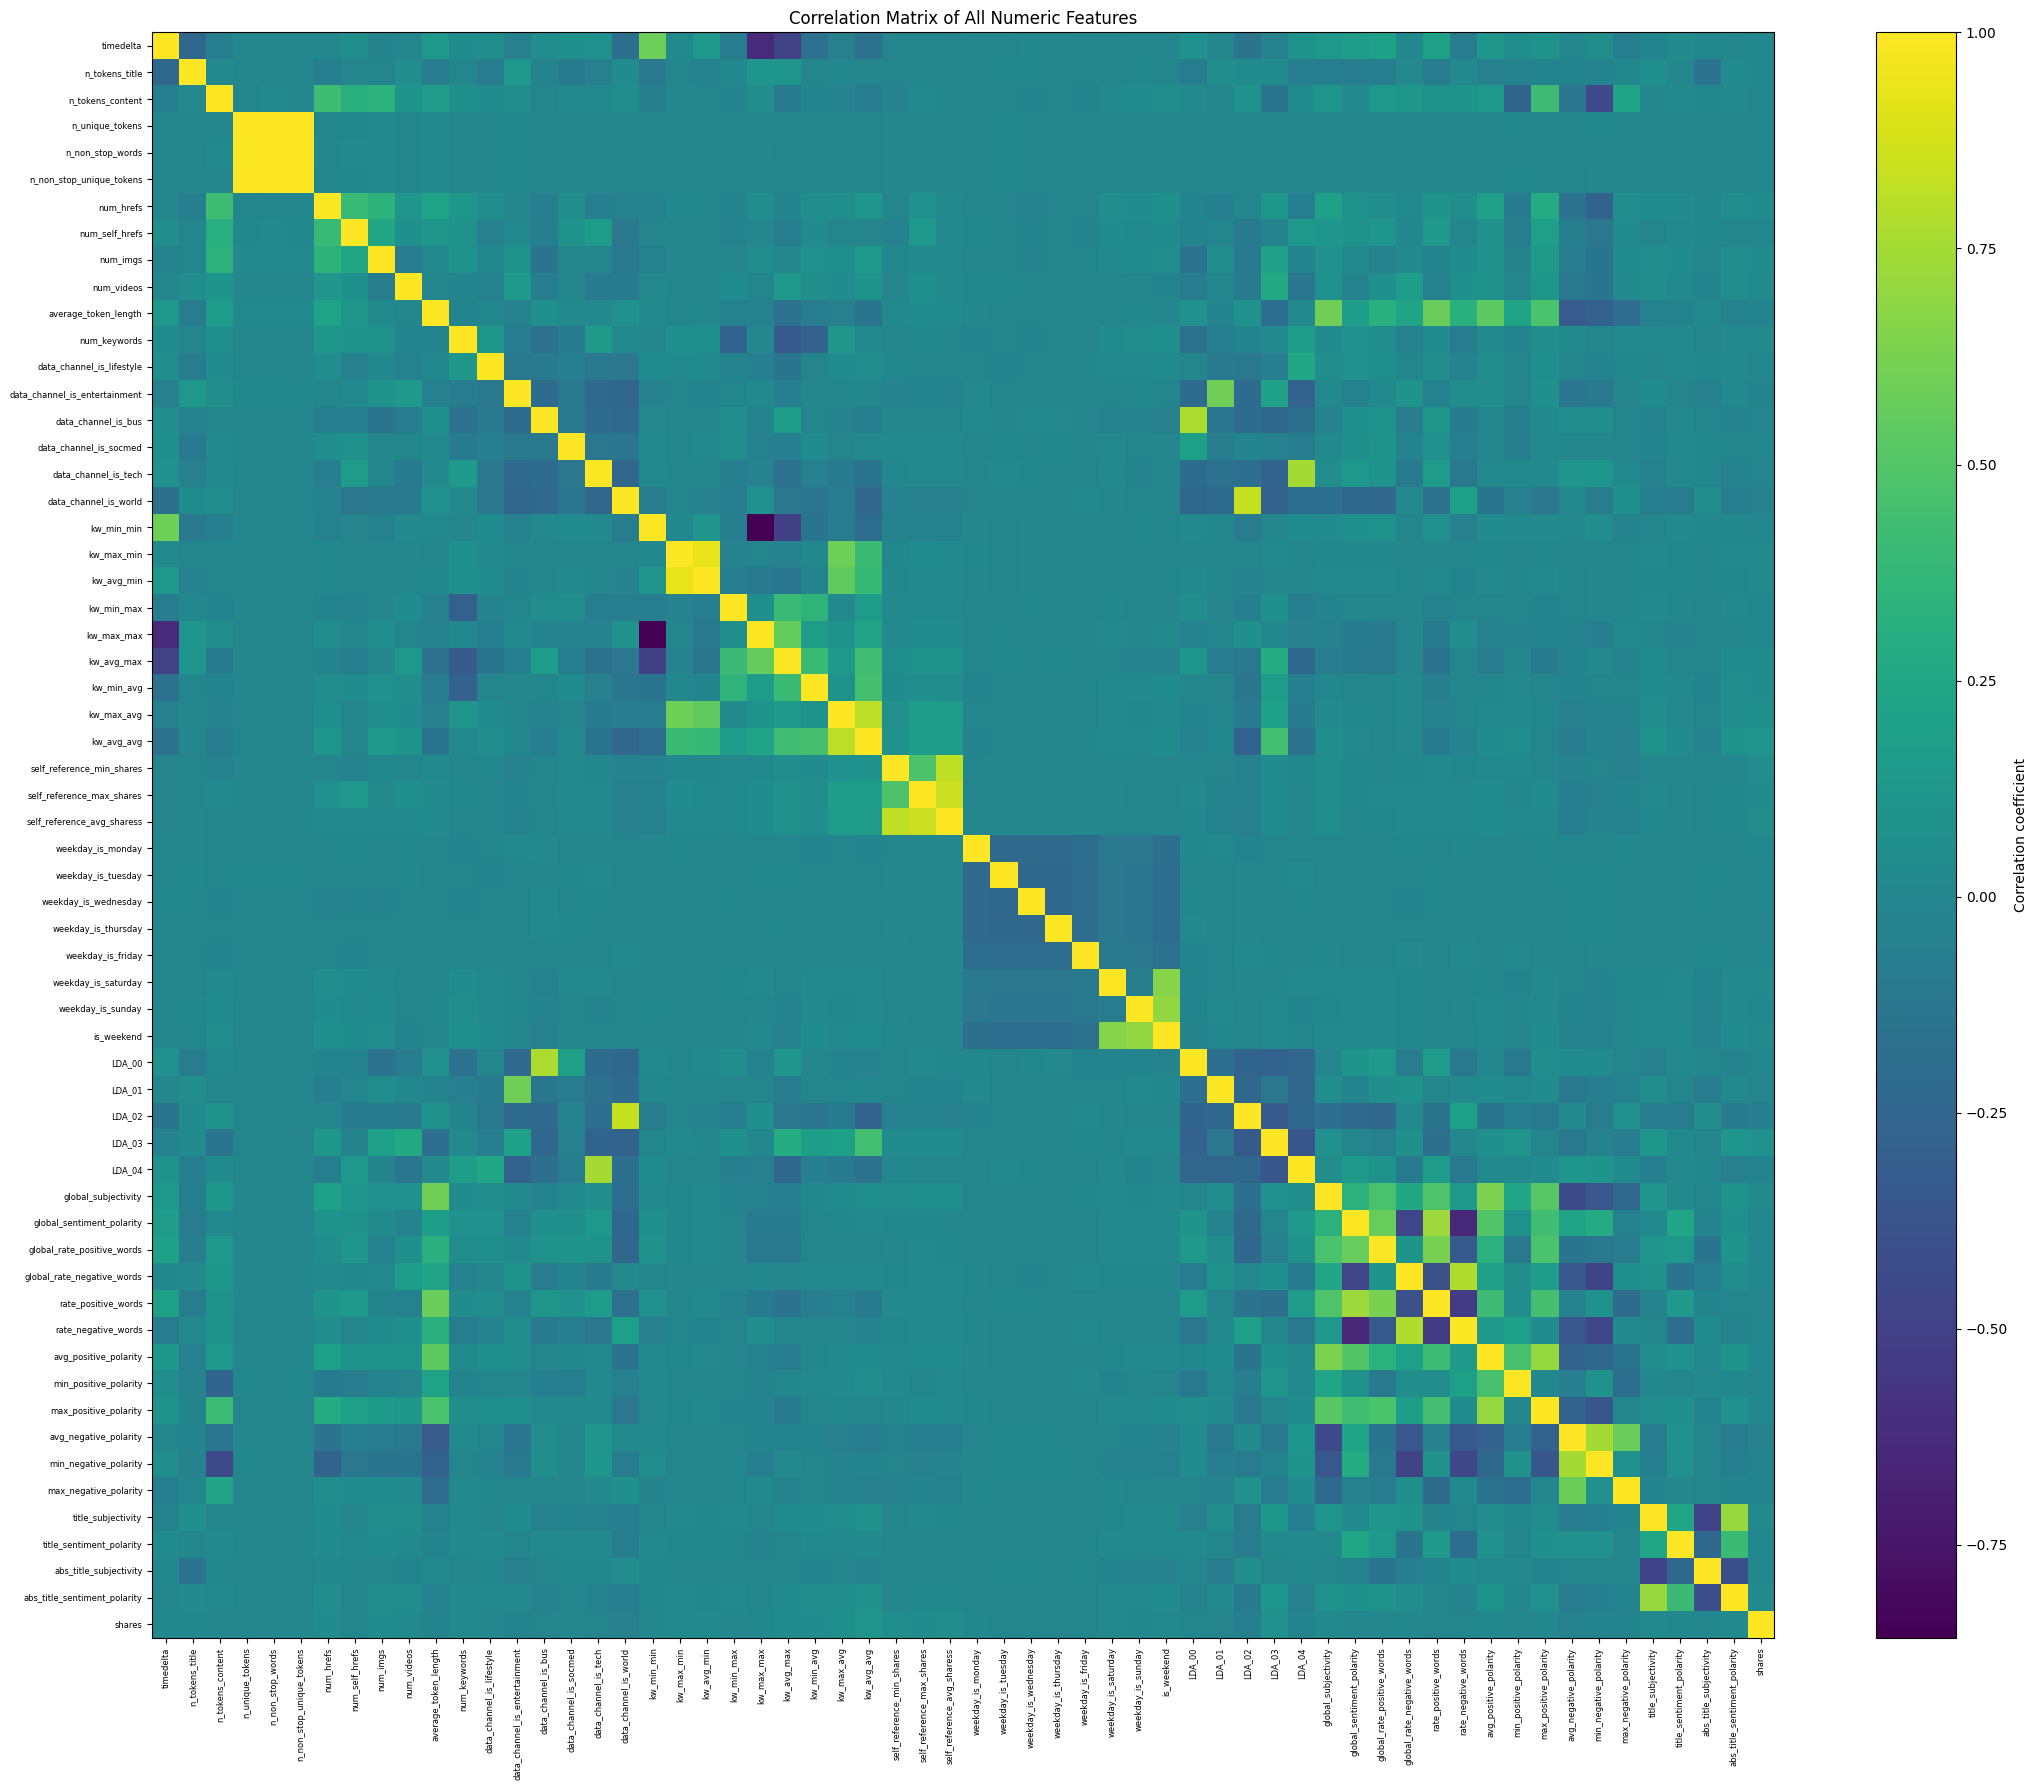

In [7]:
plt.figure(figsize=(22, 18))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Correlation coefficient")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90, fontsize=6)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns, fontsize=6)
plt.title("Correlation Matrix of All Numeric Features")
plt.tight_layout()
plt.show()

In [8]:
df["kw_worst_mean"] = df[["kw_min_min", "kw_max_min", "kw_avg_min"]].mean(axis=1)
df["kw_best_mean"]  = df[["kw_min_max", "kw_max_max", "kw_avg_max"]].mean(axis=1)
df["kw_avg_mean"]   = df[["kw_min_avg", "kw_max_avg", "kw_avg_avg"]].mean(axis=1)

df = df.drop(columns=[
    "kw_min_min", "kw_max_min", "kw_avg_min",
    "kw_min_max", "kw_max_max", "kw_avg_max",
    "kw_min_avg", "kw_max_avg", "kw_avg_avg"
])

In [9]:
df["self_reference_mean_shares"] = df[
    ["self_reference_min_shares",
     "self_reference_max_shares",
     "self_reference_avg_sharess"]
].mean(axis=1)

df = df.drop(columns=[
    "self_reference_min_shares",
    "self_reference_max_shares",
    "self_reference_avg_sharess"
])

In [10]:
df["content_sentiment_strength"] = (
    df["global_rate_positive_words"] +
    df["global_rate_negative_words"]
)

df = df.drop(columns=[
    "global_rate_positive_words",
    "global_rate_negative_words"
])

df["content_polarity_range"] = (
    df["max_positive_polarity"] - df["min_negative_polarity"]
)

df = df.drop(columns=[
    "max_positive_polarity",
    "min_negative_polarity"
])

In [11]:
n_rows, n_cols = df.shape
print(f"Dataset shape after aggregation: {n_rows} rows, {n_cols} columns")

Dataset shape after aggregation: 39644 rows, 51 columns


In [12]:
# Identify weekday dummy columns
weekday_cols = [c for c in df.columns if c.startswith("weekday_is_")]

# Create categorical weekday variable
df["weekday"] = (
    df[weekday_cols]
    .idxmax(axis=1)
    .str.replace("weekday_is_", "")
)

# Drop redundant columns
df = df.drop(columns=weekday_cols + ["is_weekend"])

In [13]:
print(df["weekday"].value_counts())
print("Number of columns after weekday removal:", df.shape[1])

weekday
wednesday    7435
tuesday      7390
thursday     7267
monday       6661
friday       5701
sunday       2737
saturday     2453
Name: count, dtype: int64
Number of columns after weekday removal: 44


In [14]:
channel_cols = [
    "data_channel_is_lifestyle",
    "data_channel_is_entertainment",
    "data_channel_is_bus",
    "data_channel_is_socmed",
    "data_channel_is_tech",
    "data_channel_is_world"
]

In [15]:
df["data_channel"] = (
    df[channel_cols]
    .idxmax(axis=1)
    .str.replace("data_channel_is_", "")
)

In [16]:
# Drop redundant columns
df = df.drop(columns=channel_cols)

In [17]:
df["data_channel"].value_counts()

data_channel
world            8427
lifestyle        8233
tech             7346
entertainment    7057
bus              6258
socmed           2323
Name: count, dtype: int64

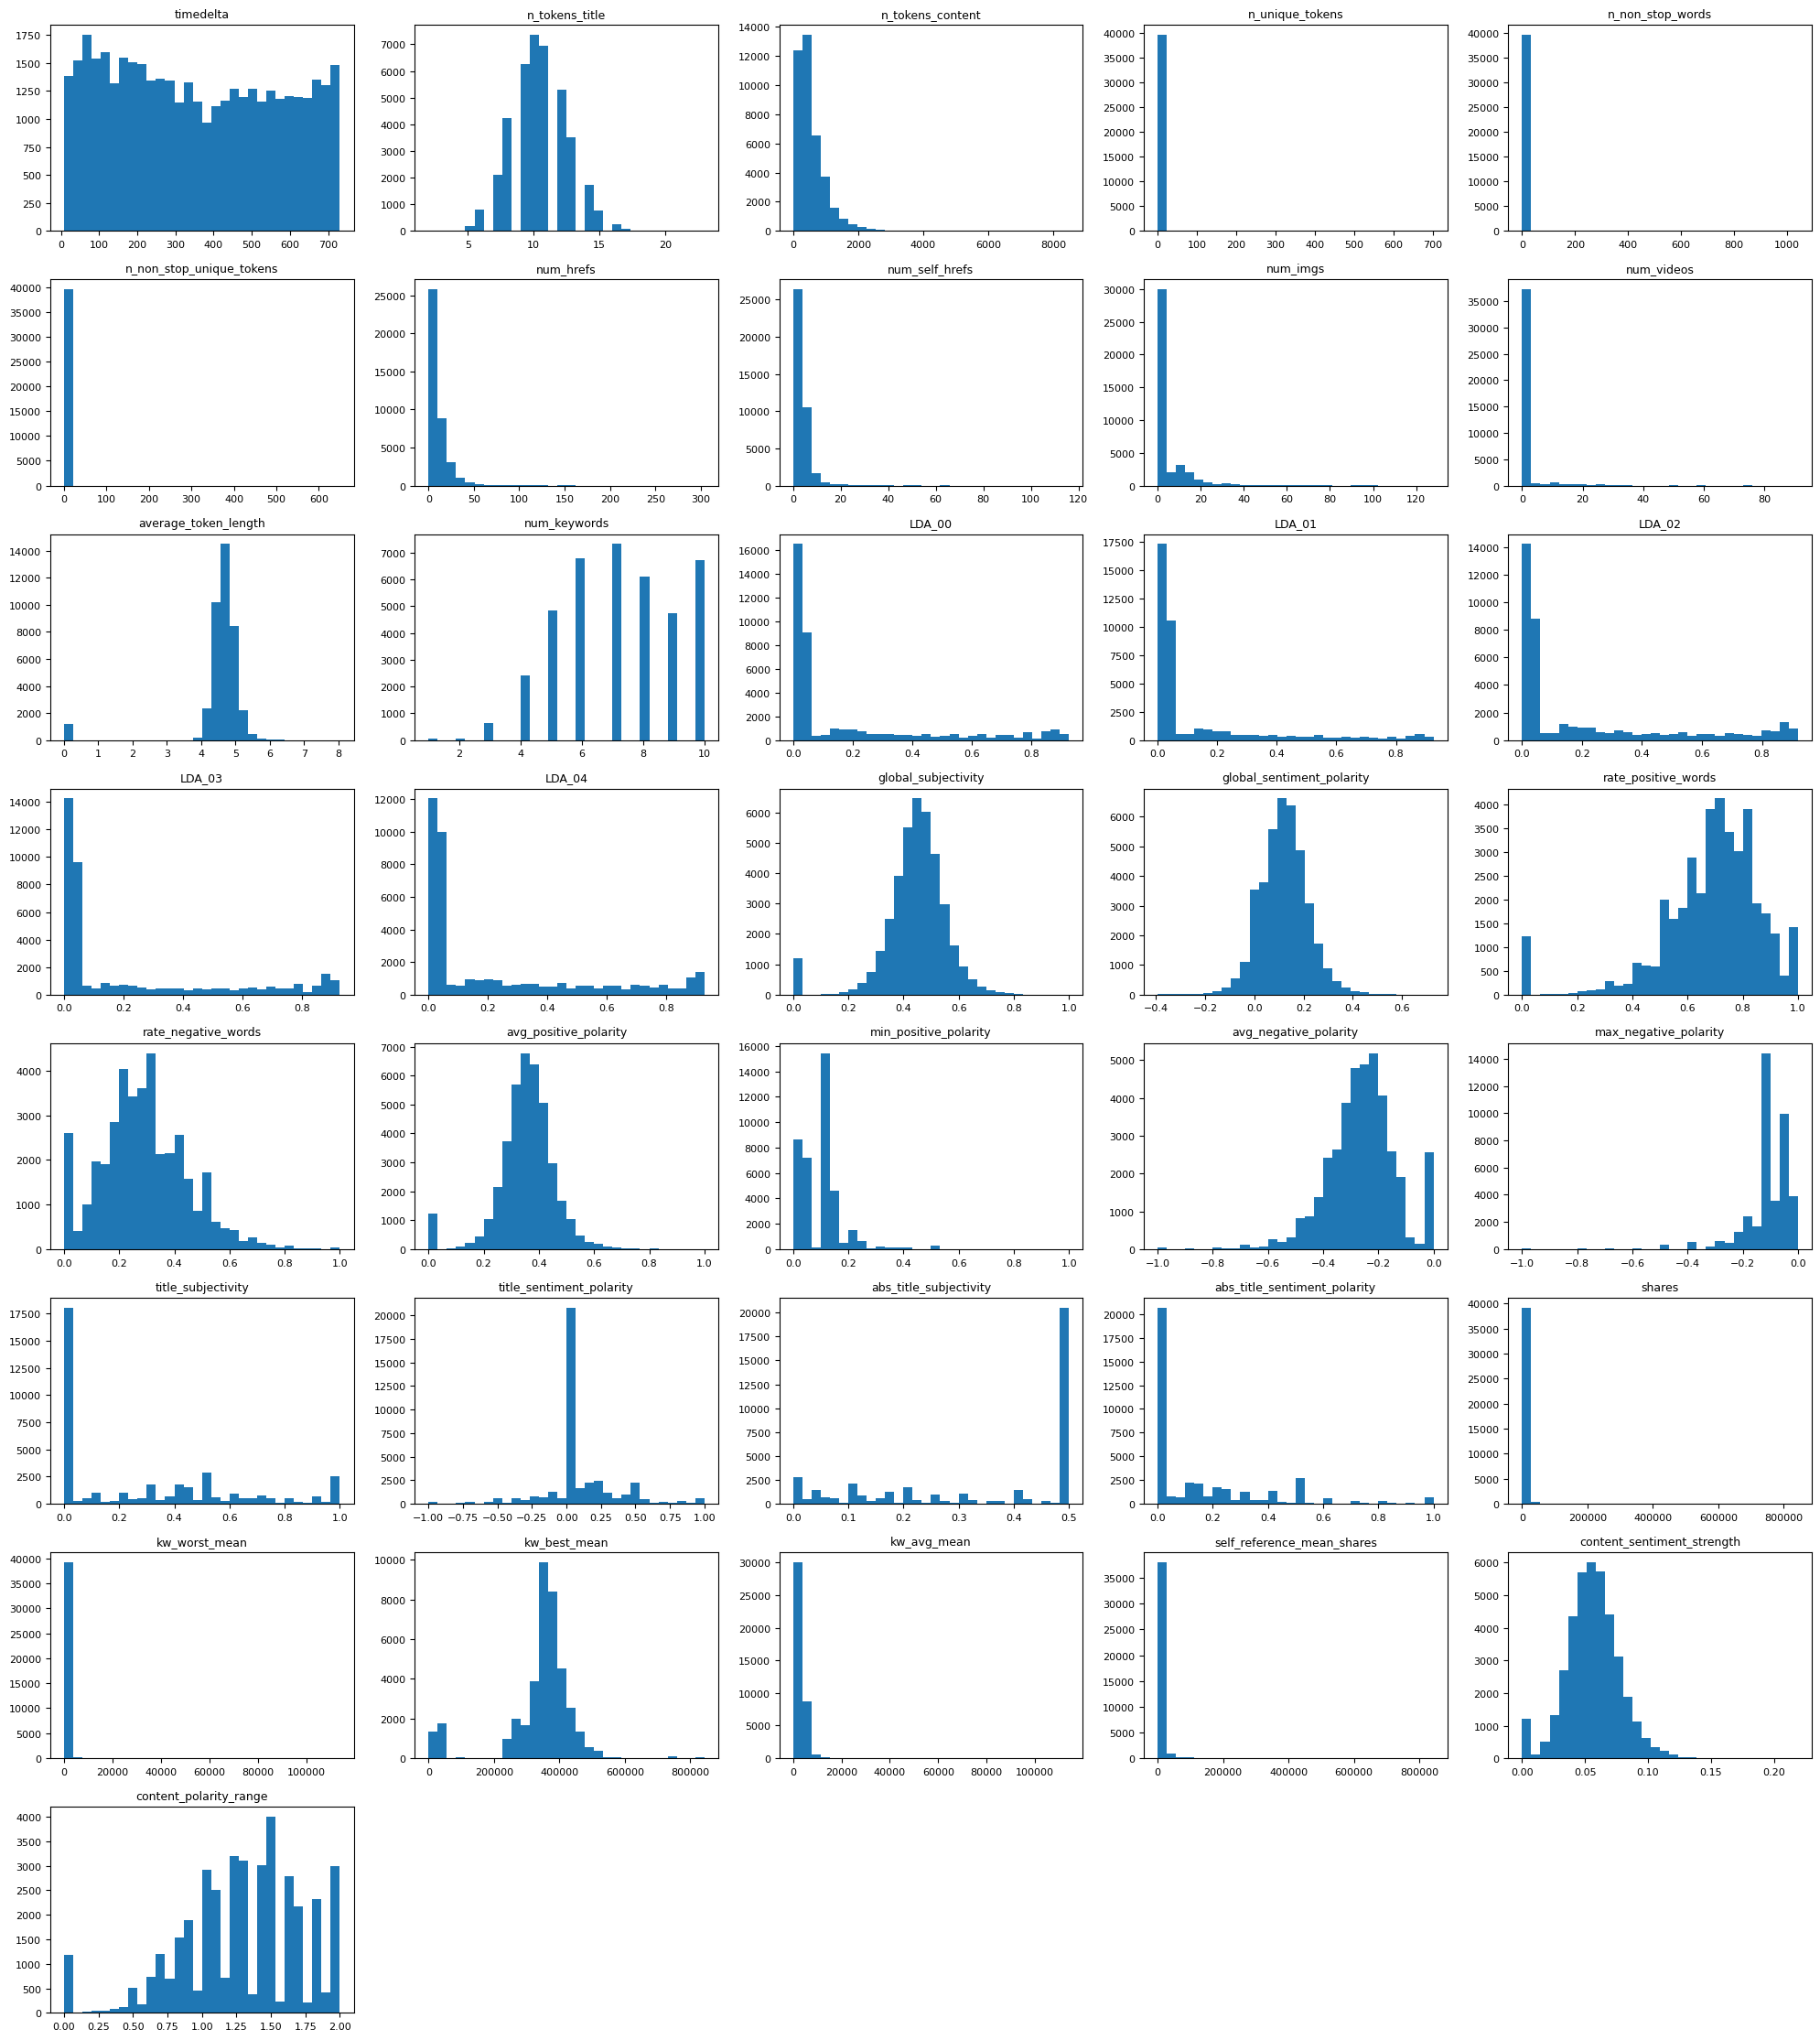

In [18]:
# Select numeric columns only, exclude target
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != "global subjectivity"]  # predictors only

# Grid layout
n_cols = 5  
n_plots = len(numeric_cols)
n_rows = math.ceil(n_plots / n_cols)

# Create the figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 2.8*n_rows))
axes = axes.flatten()

# Plot each histogram
for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=30)
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(axis="both", labelsize=8)

# Hide unused subplots (if any)
for j in range(n_plots, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

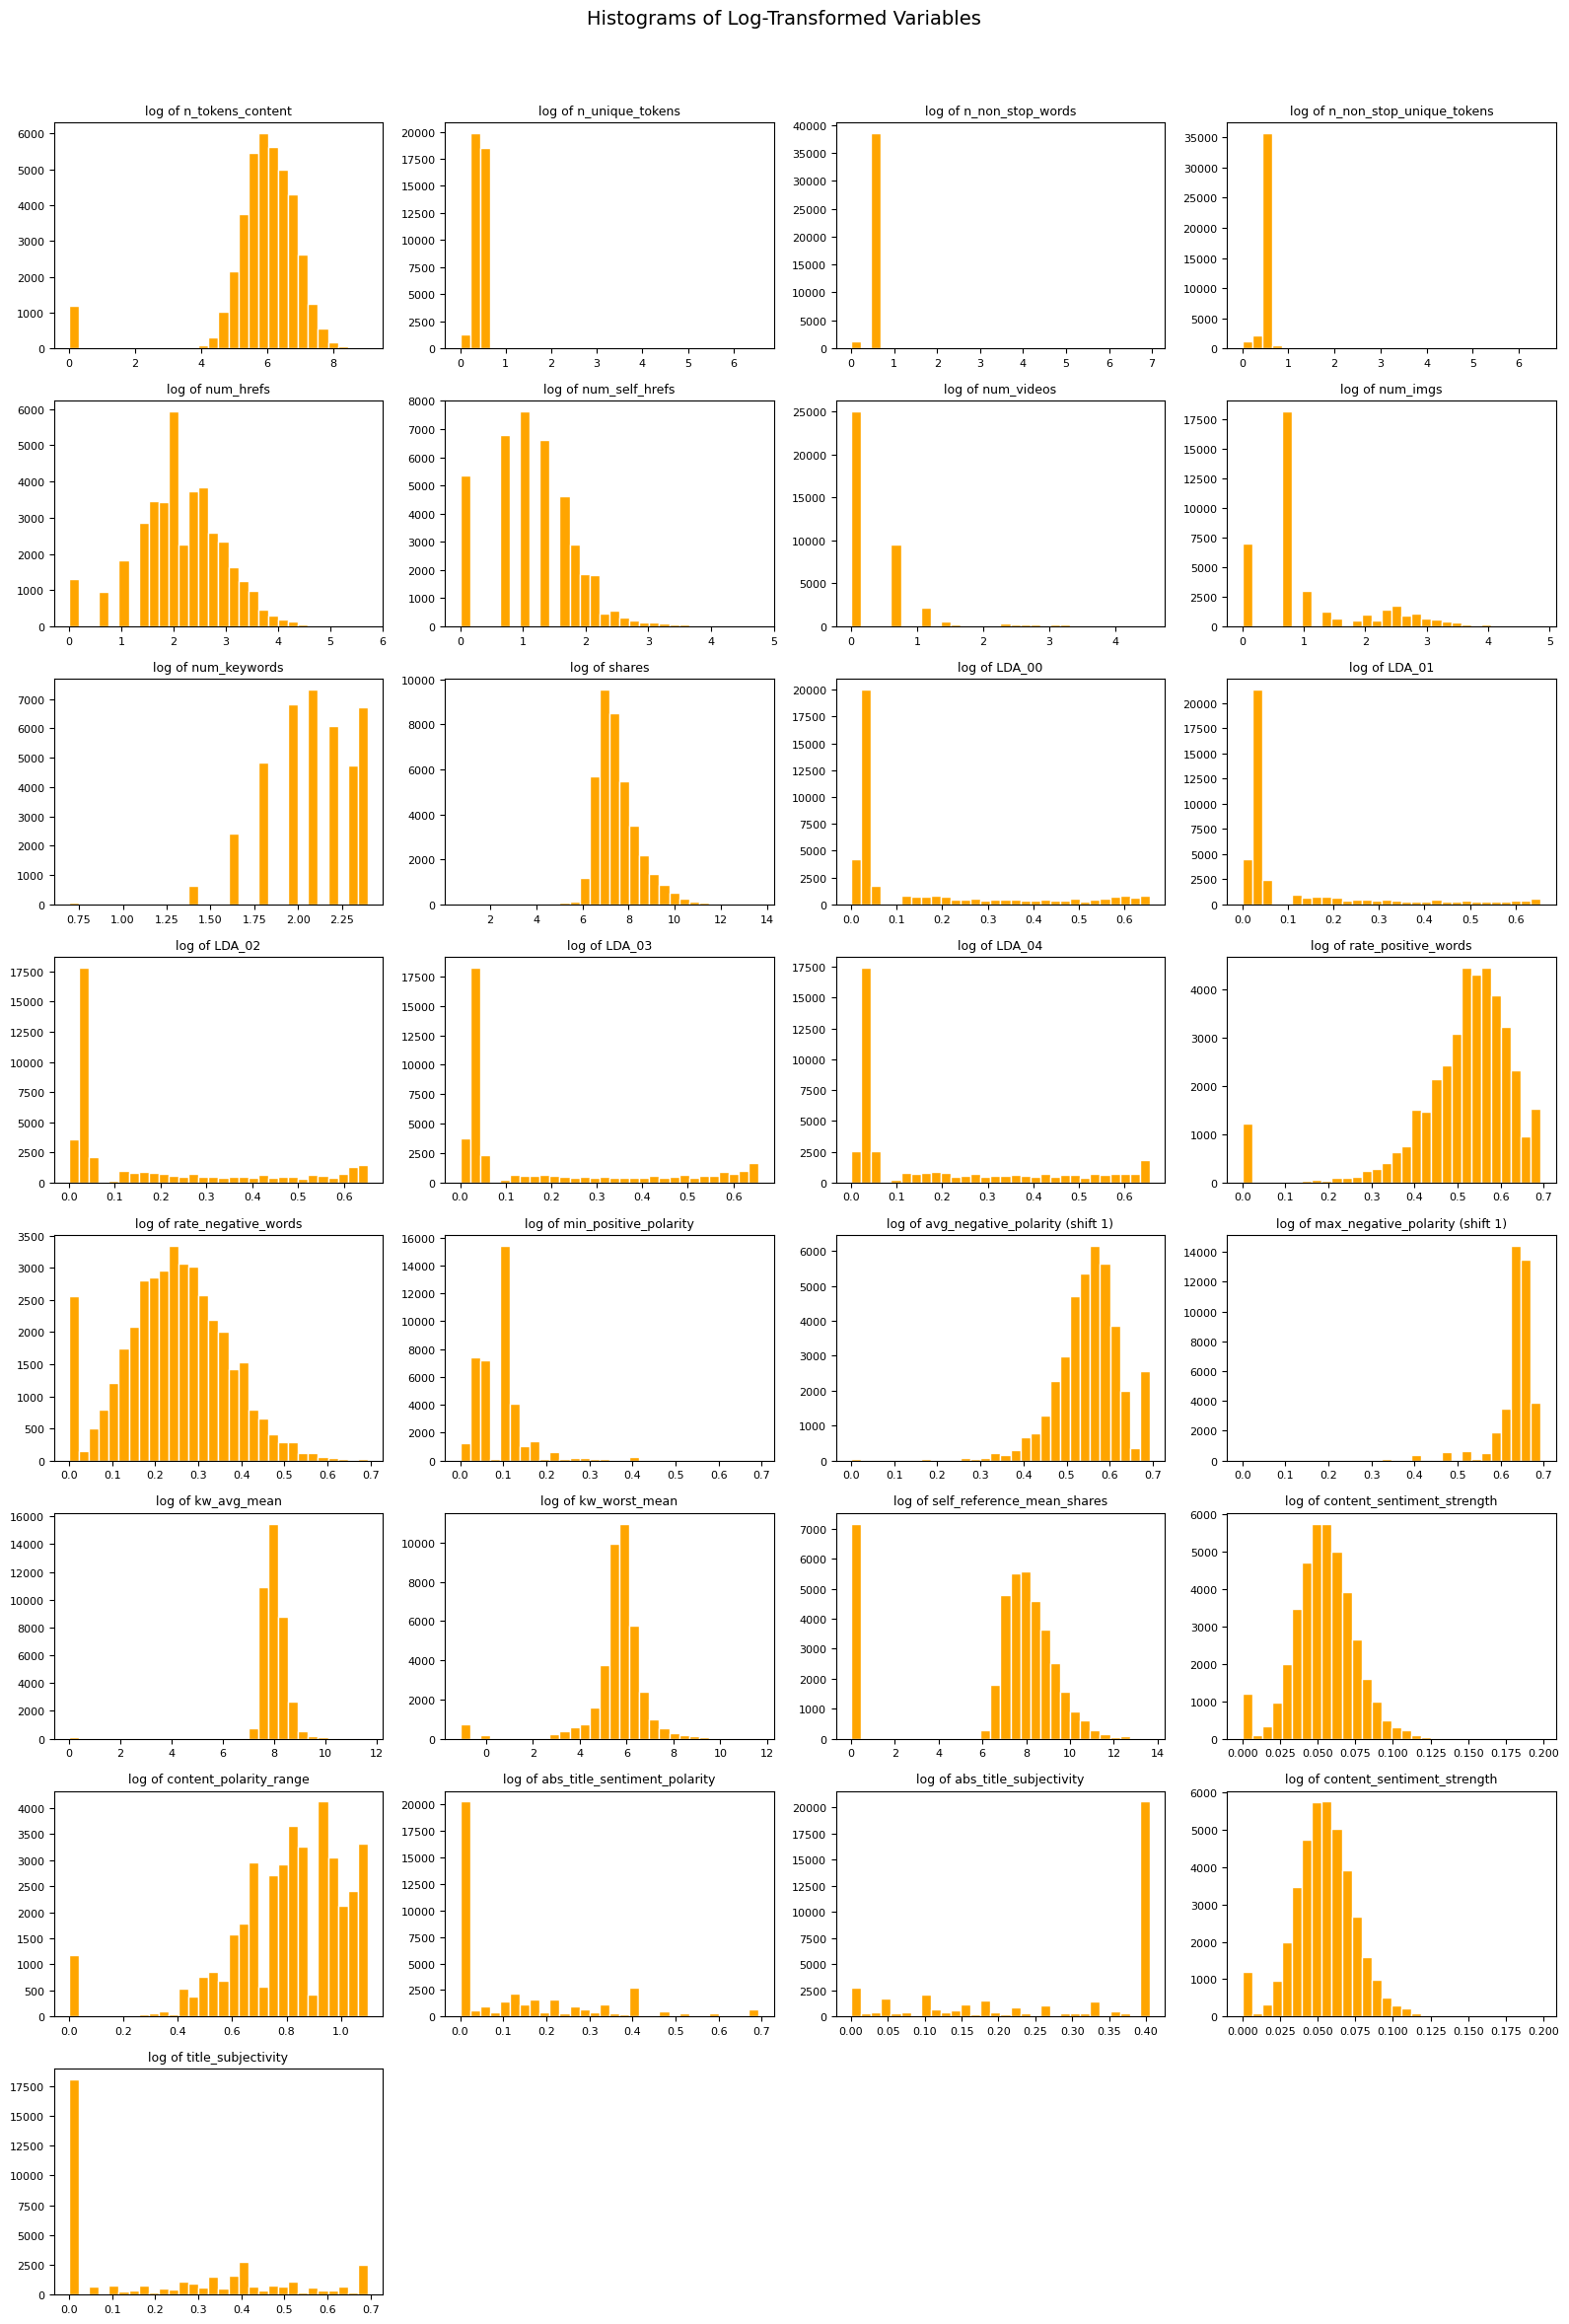

In [19]:
log_vars = [
    "n_tokens_content", "n_unique_tokens", "n_non_stop_words",
    "n_non_stop_unique_tokens", "num_hrefs", "num_self_hrefs",
    "num_videos", "num_imgs", "num_keywords", "shares",
    "LDA_00", "LDA_01", "LDA_02", "LDA_03", "LDA_04",
    "rate_positive_words", "rate_negative_words",
    "min_positive_polarity", "avg_negative_polarity", "max_negative_polarity",
    "kw_avg_mean", "kw_worst_mean","self_reference_mean_shares",
    "content_sentiment_strength", "content_polarity_range",
    "abs_title_sentiment_polarity", "abs_title_subjectivity",
    "content_sentiment_strength", "title_subjectivity", 
]

log_vars = [c for c in log_vars if c in df.columns]

n_cols = 4
n_plots = len(log_vars)
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axes = np.array(axes).flatten()

for i, col in enumerate(log_vars):
    raw = df[col].dropna()

    # Shift if needed so all values are > -1 for log1p
    min_val = raw.min()
    shift = (-min_val + 1e-6) if min_val <= -1 else 0.0

    data = np.log1p(raw + shift)

    axes[i].hist(data, bins=30, color="orange", edgecolor="white")
    if shift > 0:
        axes[i].set_title(f"log of {col} (shift {shift:.3g})", fontsize=9)
    else:
        axes[i].set_title(f"log of {col}", fontsize=9)
    axes[i].tick_params(axis="both", labelsize=8)

for j in range(n_plots, len(axes)):
    axes[j].axis("off")

plt.suptitle("Histograms of Log-Transformed Variables", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [20]:
# Drop specified (possibly already-removed) columns safely and report outcome
cols_to_drop = [
    "url",
    "timedelta",
    "n_unique_tokens",
    "n_non_stop_words",
    "n_non_stop_unique_tokens",
    "num_videos",\
    "num_imgs",
    "num_self_hrefs",
    "LDA_00",
    "LDA_01",
    "LDA_02",
    "LDA_03",
    "LDA_04",
    "min_positive_polarity",
    "max_negative_polarity",
    "rate_negative_words",
    "content_polarity_range",
    "abs_title_sentiment_polarity",
    "abs_title_subjectivity",
    "title_subjectivity"
]
existing = [c for c in cols_to_drop if c in df.columns]
missing = [c for c in cols_to_drop if c not in df.columns]

if existing:
    df.drop(columns=existing, inplace=True, errors="ignore")

print(f"Dropped columns ({len(existing)}): {existing}")
if missing:
    print(f"Ignored (not present): {missing}")
print("New dataframe shape:", df.shape)

Dropped columns (20): ['url', 'timedelta', 'n_unique_tokens', 'n_non_stop_words', 'n_non_stop_unique_tokens', 'num_videos', 'num_imgs', 'num_self_hrefs', 'LDA_00', 'LDA_01', 'LDA_02', 'LDA_03', 'LDA_04', 'min_positive_polarity', 'max_negative_polarity', 'rate_negative_words', 'content_polarity_range', 'abs_title_sentiment_polarity', 'abs_title_subjectivity', 'title_subjectivity']
New dataframe shape: (39644, 19)


In [21]:
df

,n_tokens_title,n_tokens_content,num_hrefs,average_token_length,num_keywords,global_subjectivity,global_sentiment_polarity,rate_positive_words,avg_positive_polarity,avg_negative_polarity,title_sentiment_polarity,shares,kw_worst_mean,kw_best_mean,kw_avg_mean,self_reference_mean_shares,content_sentiment_strength,weekday,data_channel
0,12.0,219.0,4.0,4.680365,5.0,0.521617,0.092562,0.769231,0.378636,-0.350000,-0.187500,593,0.000000,0.000000,0.000000,496.000000,0.059361,monday,entertainment
1,9.0,255.0,3.0,4.913725,4.0,0.341246,0.148948,0.733333,0.286915,-0.118750,0.000000,711,0.000000,0.000000,0.000000,0.000000,0.058824,monday,bus
2,9.0,211.0,3.0,4.393365,6.0,0.702222,0.323333,0.857143,0.495833,-0.466667,0.000000,1500,0.000000,0.000000,0.000000,918.000000,0.066351,monday,bus
3,9.0,531.0,9.0,4.404896,7.0,0.429850,0.100705,0.666667,0.385965,-0.369697,0.000000,1200,0.000000,0.000000,0.000000,0.000000,0.062147,monday,entertainment
4,13.0,1072.0,19.0,4.682836,7.0,0.513502,0.281003,0.860215,0.411127,-0.220192,0.136364,505,0.000000,0.000000,0.000000,6565.385965,0.086754,monday,tech
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39639,11.0,346.0,9.0,4.523121,8.0,0.482679,0.141964,0.722222,0.333791,-0.260000,0.000000,1800,281.041667,415054.166667,3183.400493,32144.444444,0.052023,wednesday,tech
39640,12.0,328.0,9.0,4.405488,7.0,0.564374,0.194249,0.812500,0.374825,-0.211111,1.000000,1900,266.333333,347595.238095,3515.365779,2100.000000,0.048780,wednesday,socmed
39641,10.0,442.0,24.0,5.076923,8.0,0.510296,0.024609,0.576923,0.307273,-0.356439,0.136364,1900,286.083333,381783.333333,4280.336194,1400.000000,0.058824,wednesday,lifestyle
39642,6.0,682.0,10.0,4.975073,5.0,0.358578,-0.008066,0.466667,0.236851,-0.205246,0.000000,1100,-0.666667,365966.666667,1720.737585,452.000000,0.043988,wednesday,world


In [22]:
# Create log-transformed columns for specified features 
cols_to_log = [
    "n_tokens_content",
    "num_hrefs",
    "num_keywords",
    "rate_positive_words",
    "avg_negative_polarity",
    "kw_avg_mean",
    "kw_worst_mean",
    "self_reference_mean_shares",
    "content_sentiment_strength",
]

created = []
skipped = []

for col in cols_to_log:
    if col not in df.columns:
        skipped.append(col)
        continue

    # shift if necessary so values > -1 for log1p
    min_val = df[col].min()
    shift = (-min_val + 1e-6) if min_val <= -1 else 0.0

    new_col = f"log_{col}"
    df[new_col] = np.log1p(df[col] + shift)
    created.append((new_col, shift))

# Report
if created:
    print("Created log columns:")
    for new_col, shift in created:
        if shift:
            print(f" - {new_col} (shifted by {shift:.6g} before log1p)")
        else:
            print(f" - {new_col}")
if skipped:
    print("Skipped (not found):", skipped)

Created log columns:
 - log_n_tokens_content
 - log_num_hrefs
 - log_num_keywords
 - log_rate_positive_words
 - log_avg_negative_polarity (shifted by 1 before log1p)
 - log_kw_avg_mean
 - log_kw_worst_mean
 - log_self_reference_mean_shares
 - log_content_sentiment_strength


In [23]:
# Drop specified columns safely
cols_to_drop = [
    "n_tokens_content",
    "num_hrefs",
    "num_keywords",
    "rate_positive_words",
    "avg_negative_polarity",
    "kw_avg_mean",
    "kw_worst_mean",
    "self_reference_mean_shares",
    "content_sentiment_strength",
]

existing = [c for c in cols_to_drop if c in df.columns]
missing = [c for c in cols_to_drop if c not in df.columns]

if existing:
    df.drop(columns=existing, inplace=True, errors="ignore")

print(f"Dropped ({len(existing)}): {existing}")
if missing:
    print(f"Not present (skipped): {missing}")
print("New dataframe shape:", df.shape)

# Update common helper lists in the notebook to avoid references to removed columns
for var in ["numeric_cols", "numeric_features", "other_numeric", "log_features", "log_feats", "predictors", "cols"]:
    if var in globals() and isinstance(globals()[var], list):
        globals()[var] = [x for x in globals()[var] if x not in cols_to_drop]


Dropped (9): ['n_tokens_content', 'num_hrefs', 'num_keywords', 'rate_positive_words', 'avg_negative_polarity', 'kw_avg_mean', 'kw_worst_mean', 'self_reference_mean_shares', 'content_sentiment_strength']
New dataframe shape: (39644, 19)


In [24]:
df

,n_tokens_title,average_token_length,global_subjectivity,global_sentiment_polarity,avg_positive_polarity,title_sentiment_polarity,shares,kw_best_mean,weekday,data_channel,log_n_tokens_content,log_num_hrefs,log_num_keywords,log_rate_positive_words,log_avg_negative_polarity,log_kw_avg_mean,log_kw_worst_mean,log_self_reference_mean_shares,log_content_sentiment_strength
0,12.0,4.680365,0.521617,0.092562,0.378636,-0.187500,593,0.000000,monday,entertainment,5.393628,1.609438,1.791759,0.570545,0.500776,0.000000,0.000000,6.208590,0.057666
1,9.0,4.913725,0.341246,0.148948,0.286915,0.000000,711,0.000000,monday,bus,5.545177,1.386294,1.609438,0.550046,0.631937,0.000000,0.000000,0.000000,0.057158
2,9.0,4.393365,0.702222,0.323333,0.495833,0.000000,1500,0.000000,monday,bus,5.356586,1.386294,1.945910,0.619039,0.427445,0.000000,0.000000,6.823286,0.064242
3,9.0,4.404896,0.429850,0.100705,0.385965,0.000000,1200,0.000000,monday,entertainment,6.276643,2.302585,2.079442,0.510826,0.488767,0.000000,0.000000,0.000000,0.060292
4,13.0,4.682836,0.513502,0.281003,0.411127,0.136364,505,0.000000,monday,tech,6.978214,2.995732,2.079442,0.620692,0.576506,0.000000,0.000000,8.789719,0.083195
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39639,11.0,4.523121,0.482679,0.141964,0.333791,0.000000,1800,415054.166667,wednesday,tech,5.849325,2.302585,2.197225,0.543615,0.553886,8.066019,5.642055,10.378026,0.050715
39640,12.0,4.405488,0.564374,0.194249,0.374825,1.000000,1900,347595.238095,wednesday,socmed,5.796058,2.302585,2.079442,0.594707,0.581595,8.165183,5.588496,7.650169,0.047628
39641,10.0,5.076923,0.510296,0.024609,0.307273,0.136364,1900,381783.333333,wednesday,lifestyle,6.093570,3.218876,2.197225,0.455476,0.496866,8.362020,5.659773,7.244942,0.057158
39642,6.0,4.975073,0.358578,-0.008066,0.236851,0.000000,1100,365966.666667,wednesday,world,6.526495,2.397895,1.791759,0.382992,0.584869,7.451089,-1.098612,6.115892,0.043048


### Target Variable Analysis

Now, our target is `global_subjectivity`.

In [25]:
# Summary of target
display(df["global_subjectivity"].describe())

count    39644.000000
mean         0.443370
std          0.116685
min          0.000000
25%          0.396167
50%          0.453457
75%          0.508333
max          1.000000
Name: global_subjectivity, dtype: float64

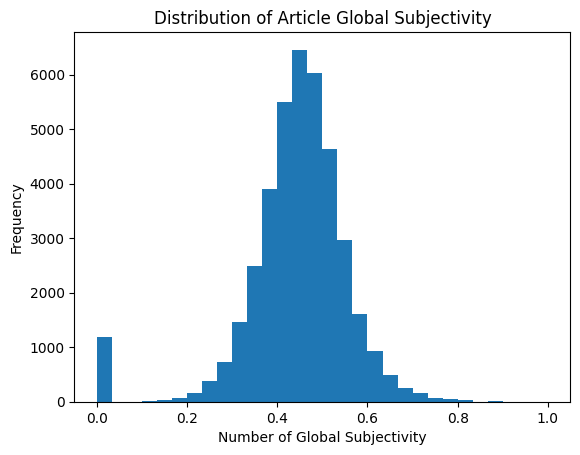

In [26]:
plt.figure()
plt.hist(df["global_subjectivity"], bins=30)
plt.xlabel("Number of Global Subjectivity")
plt.ylabel("Frequency")
plt.title("Distribution of Article Global Subjectivity")
plt.show()

Global subjectivity ranges from 0 to 1 and is centered around ~0.44. The median (0.453) is close to the mean (0.443), so the distribution is fairly balanced with a slight spread (std ~0.117). Most articles fall between ~0.40 and ~0.51, meaning content is moderately subjective overall, with few extremely objective (near 0) or fully subjective (near 1) cases.

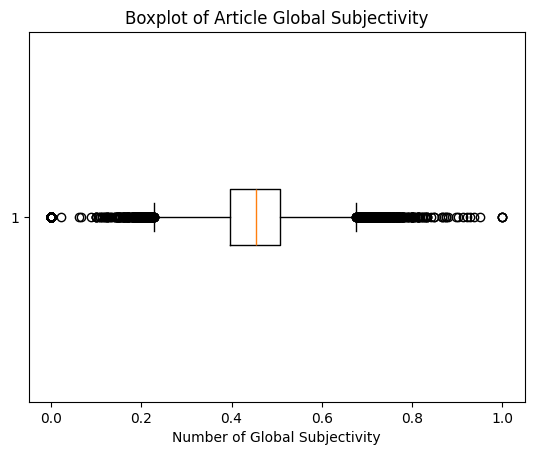

In [27]:
plt.figure()
plt.boxplot(df["global_subjectivity"], vert=False)
plt.xlabel("Number of Global Subjectivity")
plt.title("Boxplot of Article Global Subjectivity")
plt.show()

The boxplot is a confirmation. There are many low and high outliers extending toward 0 and 1, but most articles cluster near the middle, indicating generally moderate subjectivity with a few very objective or very subjective cases.

### Predictor vs Target Variable

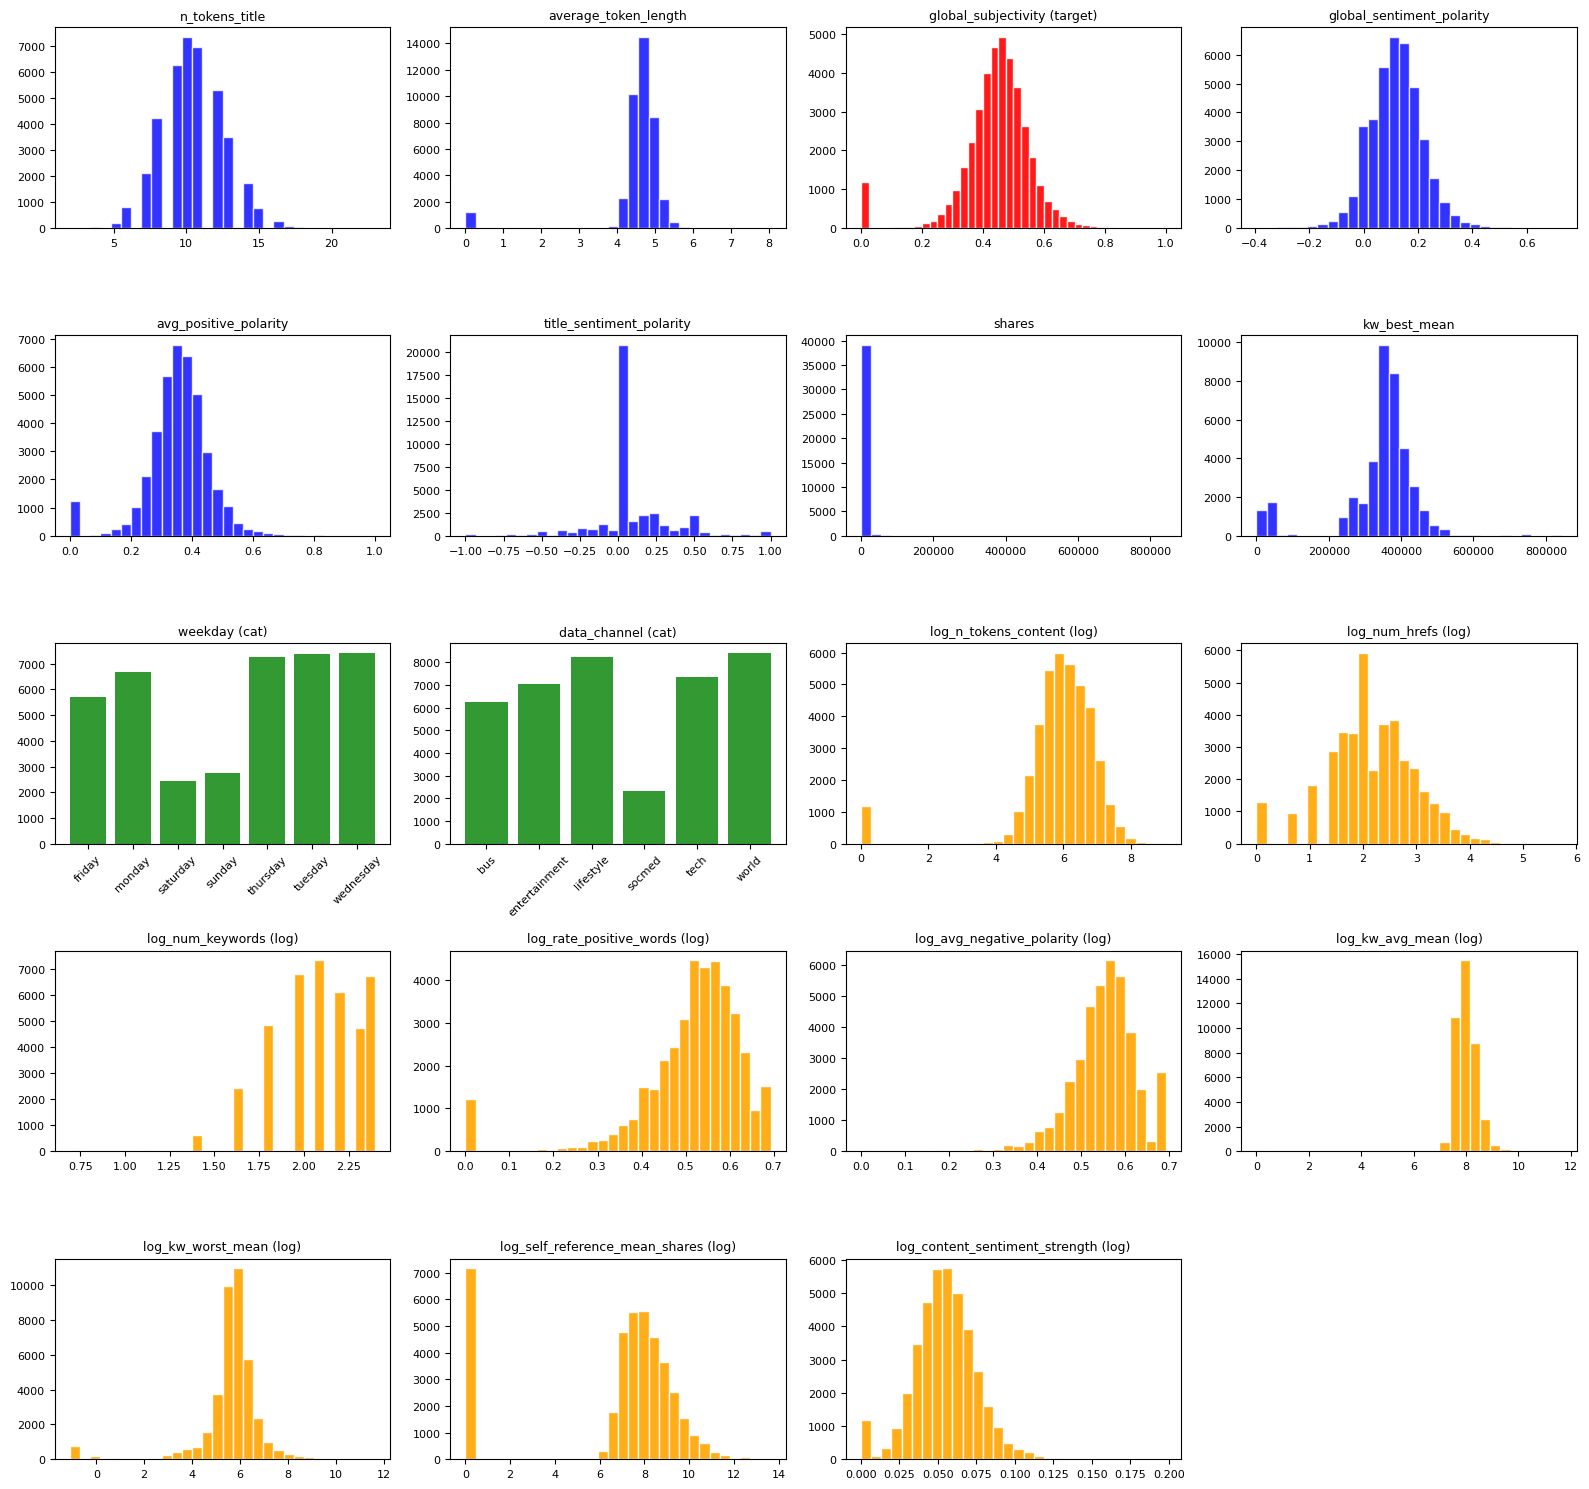

In [28]:
# Plot all features in a 4-column grid with color coding:
# - categorical: green
# - target 'log_shares': red
# - logarithmized features (start with 'log_'): orange
# - other numeric features: blue

cols = df.columns.tolist()
n_cols = 4
n_plots = len(cols)
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()

cat_color = "green"
target_color = "red"
log_color = "orange"
num_color = "blue"

for i, col in enumerate(cols):
    ax = axes[i]
    series = df[col].dropna()

    if col == "global_subjectivity":
        # target (red)
        ax.hist(series, bins=40, color=target_color, edgecolor="white", alpha=0.9)
        ax.set_title(col + " (target)", fontsize=9)
    elif isinstance(df[col].dtype, np.dtype) and df[col].dtype == object:
        # categorical (green) -> bar plot of counts
        vc = series.value_counts().sort_index()
        ax.bar(vc.index.astype(str), vc.values, color=cat_color, alpha=0.8)
        ax.set_title(col + " (cat)", fontsize=9)
        ax.tick_params(axis="x", rotation=45)
    elif col.startswith("log_"):
        # log-transformed features (orange)
        ax.hist(series, bins=30, color=log_color, edgecolor="white", alpha=0.9)
        ax.set_title(col + " (log)", fontsize=9)
    else:
        # other numeric features (blue)
        ax.hist(series, bins=30, color=num_color, edgecolor="white", alpha=0.8)
        ax.set_title(col, fontsize=9)

    ax.tick_params(axis="both", labelsize=8)

# Hide any unused subplots
for j in range(n_plots, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [29]:
# Print current features in the dataframe `df`
all_columns = df.columns.tolist()

print("All columns (in df):")
for col in all_columns:
    print(f"- {col}")

df.shape

All columns (in df):
- n_tokens_title
- average_token_length
- global_subjectivity
- global_sentiment_polarity
- avg_positive_polarity
- title_sentiment_polarity
- shares
- kw_best_mean
- weekday
- data_channel
- log_n_tokens_content
- log_num_hrefs
- log_num_keywords
- log_rate_positive_words
- log_avg_negative_polarity
- log_kw_avg_mean
- log_kw_worst_mean
- log_self_reference_mean_shares
- log_content_sentiment_strength


(39644, 19)

### Train-Test Split

In [30]:
#Train / test split using log_shares as target
X = df.drop(columns=["global_subjectivity"])
y = df["global_subjectivity"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_test: ", y_test.shape)

X_train: (31715, 18)
X_test:  (7929, 18)
y_train: (31715,)
y_test:  (7929,)


In [31]:
# Encode categorical columns
categorical_features = [c for c in ["weekday", "data_channel"] if c in X_train.columns]
numeric_features = [c for c in X_train.columns if c not in categorical_features]

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("scaler", StandardScaler()),
        ]), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
    ],
    remainder="drop"
)


# 4. Modelling

We develop models in the exactly same way, as previously. We also wanted to check, how the encoding improves the scores in this case, so we ran the baseline models without encoding and put the outcomes in the screenshots below each model. It is visible that encoding improved the results, maybe not in a very significant way, but for all models the improvement is clear.

## Random Forest

In [32]:
rf_model = Pipeline(steps=[
("preprocess", preprocess),
("model", RandomForestRegressor(
n_estimators=300,
random_state=42,
n_jobs=-1
))
])

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest RMSE: {rmse_rf:.3f}")
print(f"Random Forest R²: {r2_rf:.3f}")


Random Forest RMSE: 0.067
Random Forest R²: 0.672


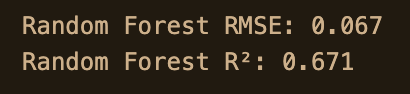

In [33]:
from sklearn.ensemble import GradientBoostingRegressor
gbr_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", GradientBoostingRegressor(random_state=42))
])

gbr_model.fit(X_train, y_train)
y_pred_gbr = gbr_model.predict(X_test)

rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
r2_gbr = r2_score(y_test, y_pred_gbr)

print(f"Gradient Boosting RMSE: {rmse_gbr:.3f}")
print(f"Gradient Boosting R²: {r2_gbr:.3f}")


Gradient Boosting RMSE: 0.068
Gradient Boosting R²: 0.666


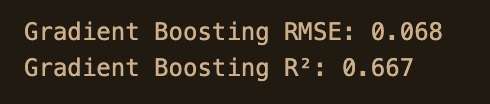

## Elastic Net

In [34]:
# Elastic Net model
en_model = Pipeline(steps=[
(   "preprocess", preprocess),
    ("model", ElasticNet(
        alpha=0.1,        
        l1_ratio=0.5,     
        random_state=42,
        max_iter=10000   
    ))
])

# Fit model
en_model.fit(X_train, y_train)

# Predict on test set
y_pred_en = en_model.predict(X_test)

# Evaluation
rmse_en = np.sqrt(mean_squared_error(y_test, y_pred_en))
r2_en = r2_score(y_test, y_pred_en)

print(f"Elastic Net RMSE: {rmse_en:.3f}")
print(f"Elastic Net R²: {r2_en:.3f}")

Elastic Net RMSE: 0.102
Elastic Net R²: 0.244


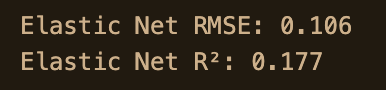

## Support Vector Regression

In [35]:
# Baseline SVR model
svr_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", SVR(
        kernel="rbf",      # radial basis function kernel (default)
        C=1.0,             # regularization strength
        epsilon=0.1        # epsilon-insensitive tube
    ))
])

# Fit model
svr_model.fit(X_train, y_train)

# Predict on test set
y_pred_svr = svr_model.predict(X_test)

# Evaluation
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
r2_svr = r2_score(y_test, y_pred_svr)

print(f"SVR Baseline RMSE: {rmse_svr:.3f}")
print(f"SVR Baseline R²: {r2_svr:.3f}")

SVR Baseline RMSE: 0.071
SVR Baseline R²: 0.637


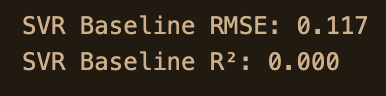

## XGBoost

In [36]:
# XGBoost model with the SAME preprocessing
xgb_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", XGBRegressor(
        n_estimators=500,        # number of trees
        learning_rate=0.05,      # step size (eta)
        max_depth=6,             # tree depth
        subsample=0.8,           # row sampling
        colsample_bytree=0.8,    # column sampling
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])

# Fit model
xgb_model.fit(X_train, y_train)

# Predict on test set
y_pred_xgb = xgb_model.predict(X_test)

# Evaluation
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost RMSE: {rmse_xgb:.3f}")
print(f"XGBoost R²: {r2_xgb:.3f}")

XGBoost RMSE: 0.066
XGBoost R²: 0.681


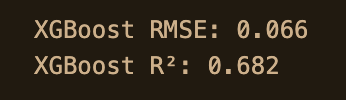

# 5. Hyperparameters Tuning

In [37]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

## Random Forest

In [38]:
rf_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

param_dist = {
    "model__n_estimators": [200, 400, 600, 800],
    "model__max_depth": [None, 8, 12, 16, 20, 24],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.5],
    "model__max_samples": [None, 0.7, 0.85, 0.95],
}

search = RandomizedSearchCV(
    rf_pipe,
    param_distributions=param_dist,
    n_iter=30,
    scoring={"rmse": make_scorer(rmse, greater_is_better=False), "r2": "r2"},
    refit="rmse",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print("Best params:", search.best_params_)

best_idx = search.best_index_
print("Best CV RMSE:", -search.best_score_)
print("Best CV R²:", search.cv_results_["mean_test_r2"][best_idx])

best_rf = search.best_estimator_
y_pred = best_rf.predict(X_test)
print("Test RMSE:", rmse(y_test, y_pred))
print("Test R²:", r2_score(y_test, y_pred))



Fitting 5 folds for each of 30 candidates, totalling 150 fits


/Users/Weronika/Library/CloudStorage/OneDrive-Osobisty/Pulpit/Data-Science/Year 2 semester 3/Machine Learning 2/ML2_final_project/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params: {'model__n_estimators': 600, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_samples': 0.95, 'model__max_features': 0.5, 'model__max_depth': None}
Best CV RMSE: 0.06535437311071114
Best CV R²: 0.6853537134913916
Test RMSE: 0.0668418229684701
Test R²: 0.6744718076550033


In [39]:
rf_search = search
y_pred_rf = y_pred

rf_cv_rmse = -rf_search.best_score_
rf_cv_r2 = rf_search.cv_results_["mean_test_r2"][rf_search.best_index_]

rf_test_rmse = rmse(y_test, y_pred_rf)
rf_test_r2 = r2_score(y_test, y_pred_rf)

### Gradient Boosting

In [40]:
gbr_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", GradientBoostingRegressor(random_state=42))
])

param_dist = {
    "model__n_estimators": [100, 200, 400],
    "model__learning_rate": [0.03, 0.05, 0.1, 0.2],
    "model__max_depth": [2, 3, 4],
    "model__subsample": [0.7, 0.85, 1.0],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
}

search = RandomizedSearchCV(
    gbr_pipe,
    param_distributions=param_dist,
    n_iter=30,
    scoring={"rmse": make_scorer(rmse, greater_is_better=False), "r2": "r2"},
    refit="rmse",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

best_idx = search.best_index_
print("Best params:", search.best_params_)
print("Best CV RMSE:", -search.best_score_)
print("Best CV R²:", search.cv_results_["mean_test_r2"][best_idx])

best_gbr = search.best_estimator_
y_pred = best_gbr.predict(X_test)
print("Test RMSE:", rmse(y_test, y_pred))
print("Test R²:", r2_score(y_test, y_pred))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'model__subsample': 0.7, 'model__n_estimators': 400, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_depth': 4, 'model__learning_rate': 0.05}
Best CV RMSE: 0.06474729944500228
Best CV R²: 0.6911738178327511
Test RMSE: 0.06648849071357474
Test R²: 0.6779042576637171


In [41]:
grb_search = search
y_pred_enet = y_pred

enet_cv_rmse = -grb_search.best_score_
enet_cv_r2 = grb_search.cv_results_["mean_test_r2"][grb_search.best_index_]

enet_test_rmse = rmse(y_test, y_pred_enet)
enet_test_r2 = r2_score(y_test, y_pred_enet)

### Elastic Net

In [42]:
enet_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", ElasticNet(random_state=42, max_iter=30000, tol=1e-4))
])

param_dist = {
    "model__alpha": np.logspace(-5, 1, 50),
    "model__l1_ratio": np.linspace(0.05, 1.0, 20),  # no 0
}

search = RandomizedSearchCV(
    enet_pipe,
    param_distributions=param_dist,
    n_iter=30,
    scoring={"rmse": make_scorer(rmse, greater_is_better=False), "r2": "r2"},
    refit="rmse",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

best_idx = search.best_index_
print("Best params:", search.best_params_)
print("Best CV RMSE:", -search.best_score_)
print("Best CV R²:", search.cv_results_["mean_test_r2"][best_idx])

best_enet = search.best_estimator_
y_pred = best_enet.predict(X_test)
print("Test RMSE:", rmse(y_test, y_pred))
print("Test R²:", r2_score(y_test, y_pred))


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'model__l1_ratio': np.float64(0.1), 'model__alpha': np.float64(4.094915062380427e-05)}
Best CV RMSE: 0.07136230752612807
Best CV R²: 0.6248902080206499
Test RMSE: 0.07344924233185988
Test R²: 0.6069329175099205


In [43]:
enet_search = search
y_pred_enet = y_pred

enet_cv_rmse = -enet_search.best_score_
enet_cv_r2 = enet_search.cv_results_["mean_test_r2"][enet_search.best_index_]

enet_test_rmse = rmse(y_test, y_pred_enet)
enet_test_r2 = r2_score(y_test, y_pred_enet)


### Support Vector Regression

In [44]:
svr_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", SVR())
])

param_dist = {
    "model__kernel": ["rbf", "poly", "sigmoid"],
    "model__C": np.logspace(-2, 2, 10),
    "model__epsilon": [0.01, 0.05, 0.1, 0.2, 0.5],
    "model__gamma": ["scale", "auto"],
    "model__degree": [2, 3, 4],  # only used for poly
}

search = RandomizedSearchCV(
    svr_pipe,
    param_distributions=param_dist,
    n_iter=30,
    scoring={"rmse": make_scorer(rmse, greater_is_better=False), "r2": "r2"},
    refit="rmse",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

best_idx = search.best_index_
print("Best params:", search.best_params_)
print("Best CV RMSE:", -search.best_score_)
print("Best CV R²:", search.cv_results_["mean_test_r2"][best_idx])

best_svr = search.best_estimator_
y_pred = best_svr.predict(X_test)
print("Test RMSE:", rmse(y_test, y_pred))
print("Test R²:", r2_score(y_test, y_pred))

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/Users/Weronika/Library/CloudStorage/OneDrive-Osobisty/Pulpit/Data-Science/Year 2 semester 3/Machine Learning 2/ML2_final_project/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params: {'model__kernel': 'rbf', 'model__gamma': 'auto', 'model__epsilon': 0.01, 'model__degree': 4, 'model__C': np.float64(0.21544346900318834)}
Best CV RMSE: 0.06490490673940816
Best CV R²: 0.6897302285640321
Test RMSE: 0.06726093632530301
Test R²: 0.670376738402805


In [45]:
svr_search = search
y_pred_svr = y_pred

svr_cv_rmse = -svr_search.best_score_
svr_cv_r2 = svr_search.cv_results_["mean_test_r2"][svr_search.best_index_]

svr_test_rmse = rmse(y_test, y_pred_svr)
svr_test_r2 = r2_score(y_test, y_pred_svr)


### XGBoost

In [46]:
xgb_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", XGBRegressor(
        random_state=42,
        n_jobs=-1,
        tree_method="hist"
    ))
])

param_dist = {
    "model__n_estimators": [200, 400, 600, 800],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__max_depth": [3, 4, 5, 6, 8],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__reg_alpha": [0, 0.01, 0.1],
    "model__reg_lambda": [1.0, 1.5, 2.0],
}

search = RandomizedSearchCV(
    xgb_pipe,
    param_distributions=param_dist,
    n_iter=30,
    scoring={"rmse": make_scorer(rmse, greater_is_better=False), "r2": "r2"},
    refit="rmse",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

best_idx = search.best_index_
print("Best params:", search.best_params_)
print("Best CV RMSE:", -search.best_score_)
print("Best CV R²:", search.cv_results_["mean_test_r2"][best_idx])

best_xgb = search.best_estimator_
y_pred = best_xgb.predict(X_test)
print("Test RMSE:", rmse(y_test, y_pred))
print("Test R²:", r2_score(y_test, y_pred))


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'model__subsample': 0.7, 'model__reg_lambda': 2.0, 'model__reg_alpha': 0.1, 'model__n_estimators': 800, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.7}
Best CV RMSE: 0.06452229138755847
Best CV R²: 0.6933559309248031
Test RMSE: 0.06648798275857931
Test R²: 0.6779091791024383


In [47]:
xgb_search = search
y_pred_xgb = y_pred

xgb_cv_rmse = -xgb_search.best_score_
xgb_cv_r2 = xgb_search.cv_results_["mean_test_r2"][xgb_search.best_index_]

xgb_test_rmse = rmse(y_test, y_pred_xgb)
xgb_test_r2 = r2_score(y_test, y_pred_xgb)


# 6. Models comparison

In [48]:
baseline_table = pd.DataFrame({
    "model": ["Random Forest", "Gradient Boosting","Elastic Net", "XGBoost", "SVR"],
    "rmse": [rmse_rf, rmse_gbr,rmse_en, rmse_xgb, rmse_svr],
    "r2":   [r2_rf, r2_gbr,r2_en, r2_xgb, r2_svr],
}).set_index("model")

display(baseline_table.round(4))

,rmse,r2
model,,
Random Forest,0.0671,0.6720
Gradient Boosting,0.0678,0.6655
Elastic Net,0.1019,0.2442
XGBoost,0.0662,0.6810
SVR,0.0706,0.6370


- XGBoost is best: lowest RMSE (0.0662) and highest R² (0.6810).
- Random Forest is a close second (RMSE 0.0671, R² 0.6720), followed by Gradient Boosting.
- SVR is noticeably weaker, and Elastic Net is clearly the worst (highest RMSE, low R²), suggesting linear relationships alone are insufficient.
- Overall, tree‑based models explain about 64–68% of variance.

In [49]:
def cv_test_row(name, search_obj):
    best_idx = search_obj.best_index_
    cv_rmse = -search_obj.best_score_
    cv_r2 = search_obj.cv_results_.get("mean_test_r2", [np.nan])[best_idx]

    best_model = search_obj.best_estimator_
    y_pred = best_model.predict(X_test)

    return {
        "model": name,
        "cv_rmse": cv_rmse,
        "cv_r2": cv_r2,
        "test_rmse": rmse(y_test, y_pred),
        "test_r2": r2_score(y_test, y_pred),
    }

rows = []
rows.append(cv_test_row("Random Forest", rf_search))
rows.append(cv_test_row("Elastic Net", enet_search))
rows.append(cv_test_row("XGBoost", xgb_search))
rows.append(cv_test_row("SVR", svr_search))
rows.append(cv_test_row("Gradient Boosting", grb_search))

cv_vs_test = pd.DataFrame(rows).set_index("model")
display(cv_vs_test.round(4))


,cv_rmse,cv_r2,test_rmse,test_r2
model,,,,
Random Forest,0.0654,0.6854,0.0668,0.6745
Elastic Net,0.0714,0.6249,0.0734,0.6069
XGBoost,0.0645,0.6934,0.0665,0.6779
SVR,0.0649,0.6897,0.0673,0.6704
Gradient Boosting,0.0647,0.6912,0.0665,0.6779


- CV and test scores are very close for all models, good generalization.
- Best performers are XGBoost and Gradient Boosting (lowest test RMSE 0.0665, highest test R² 0.6779).
- Random Forest and SVR are slightly behind but still strong.
- Elastic Net is clearly weaker, indicating linear structure alone doesn’t capture the patterns well.

Compared to the baseline table:

- Elastic Net improves a lot (RMSE 0.1019 → 0.0734, R² 0.244 → 0.607).
- SVR improves (RMSE 0.0706 → 0.0673, R² 0.637 → 0.670).
- Gradient Boosting improves (RMSE 0.0678 → 0.0665, R² 0.666 → 0.678).
- Random Forest is roughly the same (tiny RMSE drop, slight R² gain).
- XGBoost is essentially flat/slightly worse (RMSE 0.0662 → 0.0665, R² 0.681 → 0.678).

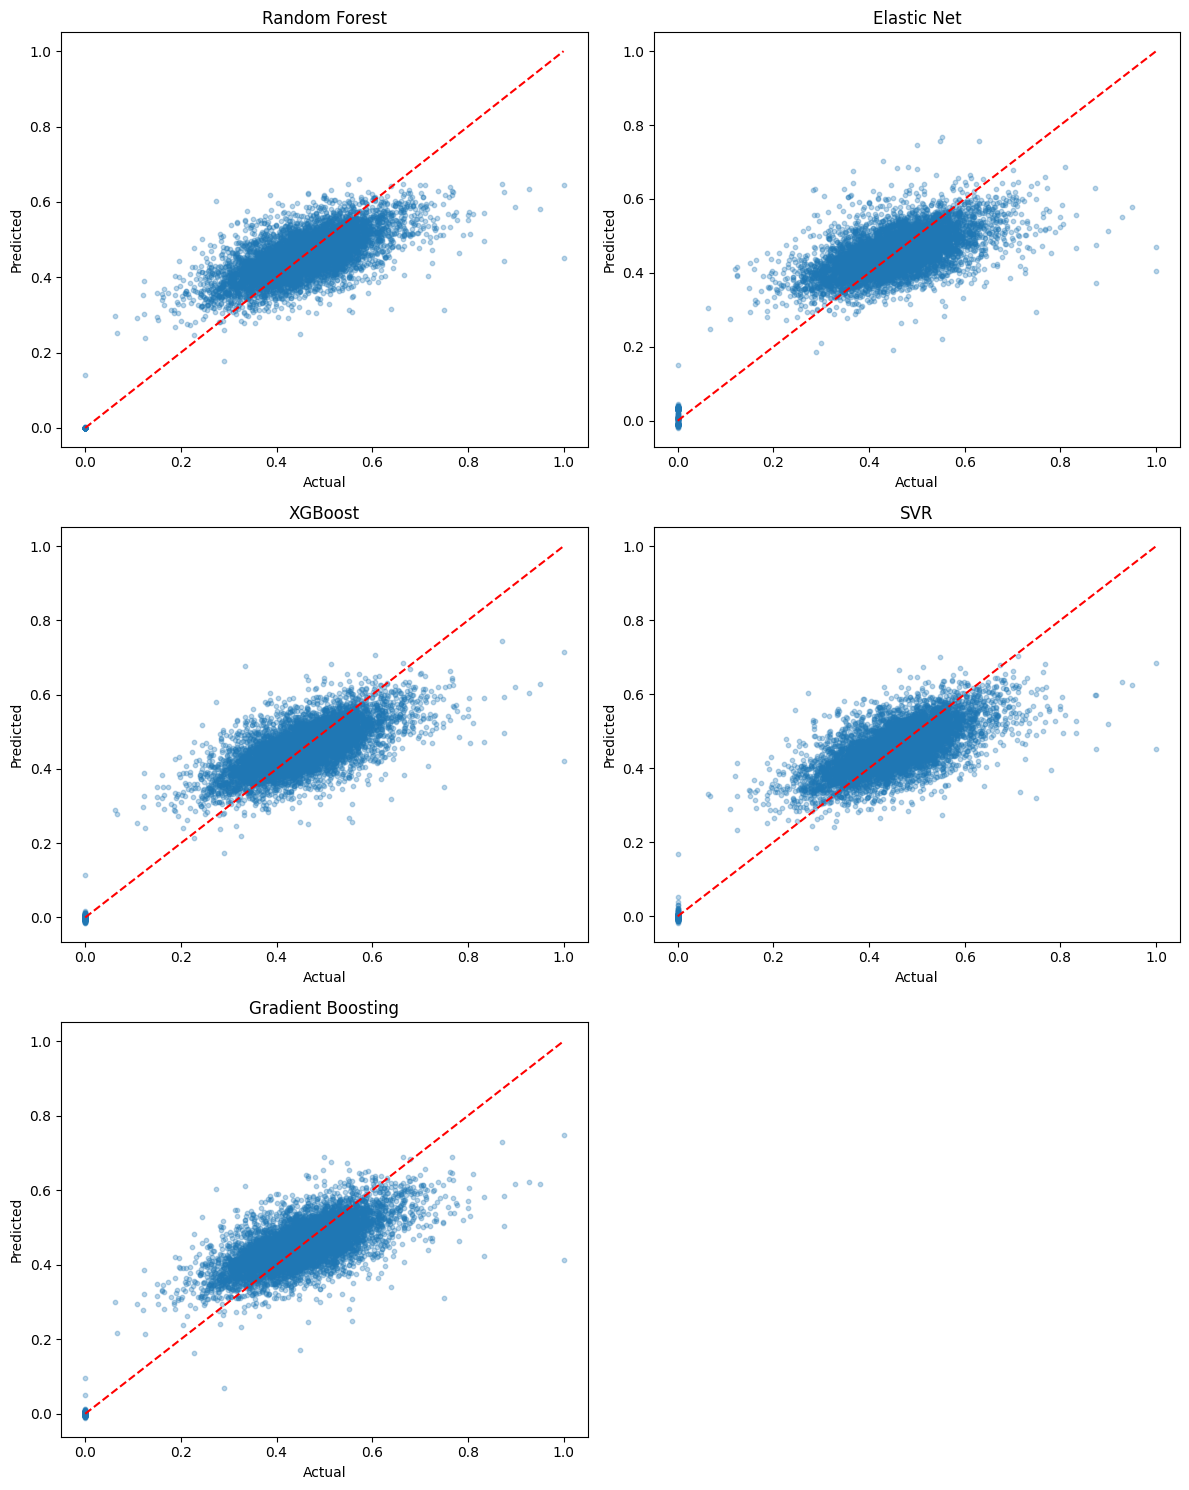

In [50]:
tuned_models = [
    ("Random Forest", best_rf),
    ("Elastic Net", best_enet),
    ("XGBoost", best_xgb),
    ("SVR", best_svr),
    ("Gradient Boosting", best_gbr),
]

n_cols = 2
n_rows = int(np.ceil(len(tuned_models) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes = np.array(axes).flatten()

y_min, y_max = y_test.min(), y_test.max()

for i, (name, model) in enumerate(tuned_models):
    y_pred = model.predict(X_test)
    ax = axes[i]
    ax.scatter(y_test, y_pred, alpha=0.3, s=10)
    ax.plot([y_min, y_max], [y_min, y_max], color="red", linestyle="--")
    ax.set_title(name)
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")

for j in range(len(tuned_models), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


In all plots, predictions follow the overall upward trend, indicating that the models successfully learn the relationship between input features and the target variable. It is still not following the trend ideally, but comparing to the shares analysis there is a major improvement.

# 7. Conclusions

Finally, we can say that our model is doing the predictions which are somehow meaningful. 

Switching the target variable from article popularity (shares) to global_subjectivity had a substantial impact on model performance and learnability. Unlike the shares target, which exhibited weak correlation with the available predictors and high intrinsic noise, global_subjectivity showed a stronger linear and nonlinear relationship with several textual features in the dataset. This resulted in significantly improved regression performance across all models.

After changing the target, cross-validation and test metrics became more consistent, with R² values in the range of 0.60–0.69 and RMSE values around 0.065–0.073, indicating that the models could explain a much larger proportion of variance in the target. Notably, ensemble models such as XGBoost and Gradient Boosting achieved the best performance, while Elastic Net remained the weakest model but still benefited from the new target formulation.

The improvement confirms that global_subjectivity is more predictable from the provided features, as it is closely tied to sentiment polarity, keyword statistics, and other text-derived signals already present in the dataset. This demonstrates that target selection plays a crucial role in defining the difficulty and feasibility of the machine learning task, and that some targets may simply be underinformed given the available feature space.

The project learned us a lot, espescially that the initial failure in getting good scores doesn't necessarily mean a failure in the whole project. Thanks to it, we dived into the topic, made research, spent time on understanding and finally decided to play with other variable, which gave better results. However, it is important to say that poor metric scores also indicate something and not always mean that the data preprocessing was done in a completly wrong way. 